<a href="https://colab.research.google.com/github/kite121/Machine-Learning-Course/blob/main/Lab_6_SWM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Lab-6 : Self-Practice

In this week self practice, you will apply [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) on multi-class problem. In the following 3-class generated blobs you will train SVCs in a one-vs-one and one-vs-rest approach. Draw the decision bounderies of each approach.

#### Question: Recall what the difference between one-vs-one and on-vs-rest for multiclass classification is.

In [63]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

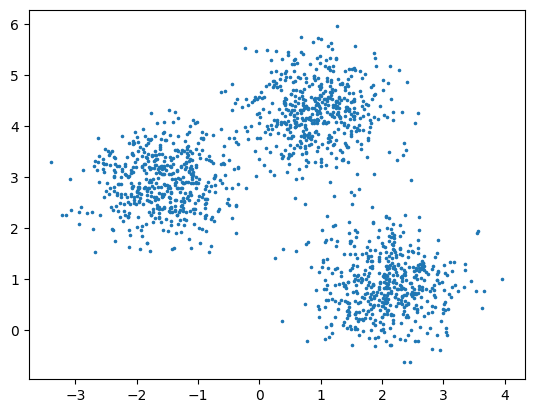

In [2]:
# we create the dataset
X, y = make_blobs(n_samples=1500, centers=3, n_features=2, cluster_std=0.60,
                  random_state=0)

plt.scatter(X[:, 0], X[:, 1],  marker=".", s=10)

### Create a svc model to classify the data point using one-vs-one approach and draw the desicion bounderies (hyperplan and margins)

In [64]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2)

In [11]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [8]:
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.svm import SVC

In [65]:
model_one = OneVsOneClassifier(SVC(kernel = 'linear', ), n_jobs = -1)
model_one.fit(X_train, y_train)

OneVsOneClassifier(estimator=SVC(kernel='linear'), n_jobs=-1)

In [66]:
def plot_regions(clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400),
    )
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.contourf(xx, yy, Z, alpha=0.25)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=10, marker=".")
    ax.set_title(title)
    return fig, ax

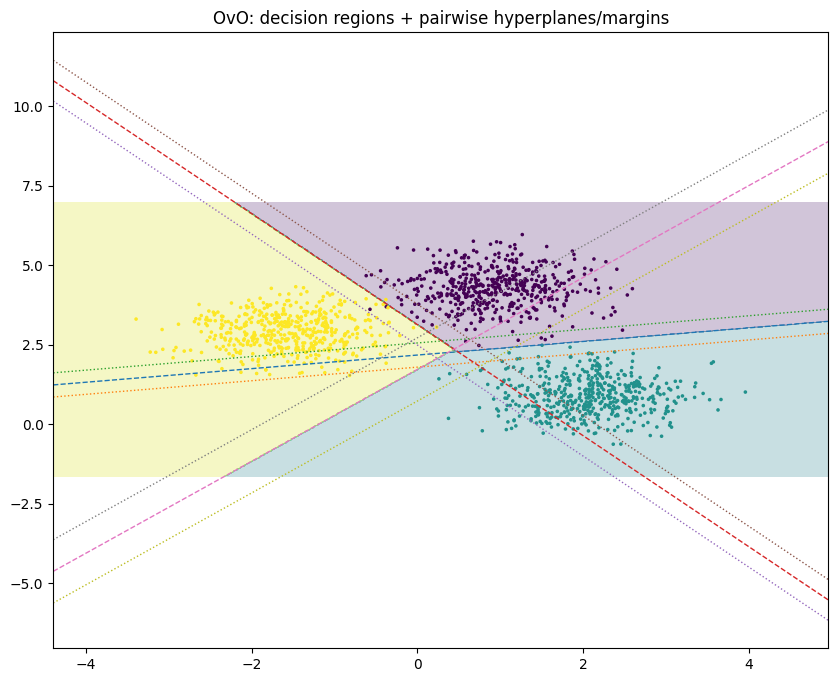

In [67]:
fig, ax = plot_regions(model_one, X, y, "OvO: decision regions + pairwise hyperplanes/margins")

# ---- Plot each pairwise hyperplane and margins (w·x + b = 0, ±1) ----
# In OvO with 3 classes -> 3 binary classifiers
for est in model_one.estimators_:
    w = est.coef_.ravel()
    b = est.intercept_[0]

    # Line: w0*x + w1*y + b = 0  -> y = -(w0*x + b)/w1
    xs = np.linspace(X[:, 0].min() - 1.0, X[:, 0].max() + 1.0, 200)
    if abs(w[1]) < 1e-12:
        # Vertical line if w1 ~ 0: x = -b/w0
        x0 = -b / w[0]
        ax.axvline(x0, linestyle="--")
        ax.axvline(x0 - 1.0 / np.linalg.norm(w), linestyle=":")
        ax.axvline(x0 + 1.0 / np.linalg.norm(w), linestyle=":")
        continue

    ys0 = -(w[0] * xs + b) / w[1]          # hyperplane
    ys1 = -(w[0] * xs + b - 1.0) / w[1]    # margin +1
    ys2 = -(w[0] * xs + b + 1.0) / w[1]    # margin -1

    ax.plot(xs, ys0, linestyle="--", linewidth=1)
    ax.plot(xs, ys1, linestyle=":", linewidth=1)
    ax.plot(xs, ys2, linestyle=":", linewidth=1)

plt.show()

### Create a svc model to classify the data points using one-vs-rest approach and draw the desicion bounderies

In [68]:
model_rest = OneVsRestClassifier(SVC(kernel = 'linear'), n_jobs = -1)
model_rest.fit(X_train, y_train)

OneVsRestClassifier(estimator=SVC(kernel='linear'), n_jobs=-1)

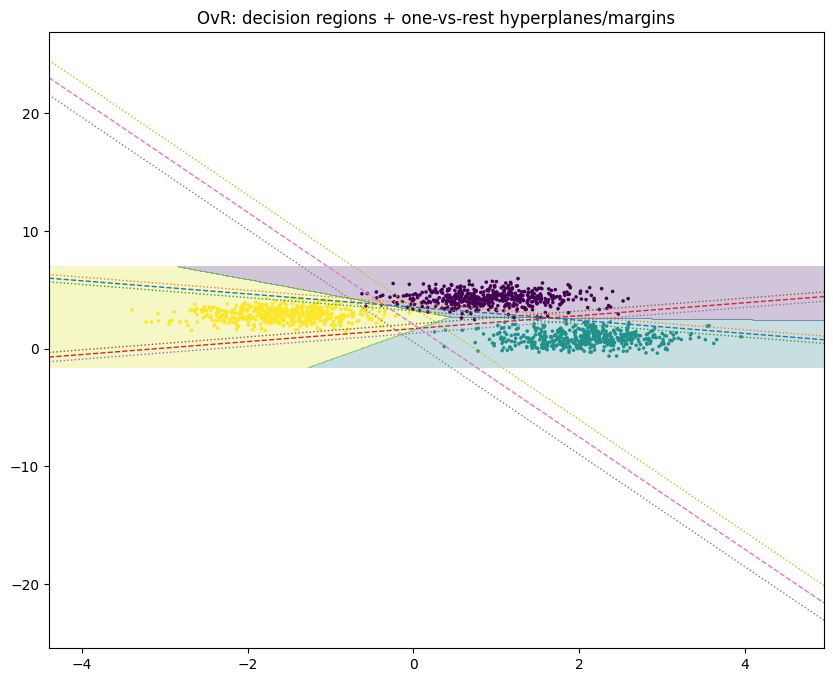

In [69]:
fig, ax = plot_regions(model_rest, X, y, "OvR: decision regions + one-vs-rest hyperplanes/margins")

# Each estimator separates its class vs the rest
for est in model_rest.estimators_:
    w = est.coef_.ravel()
    b = est.intercept_[0]

    xs = np.linspace(X[:, 0].min() - 1.0, X[:, 0].max() + 1.0, 200)
    if abs(w[1]) < 1e-12:
        x0 = -b / w[0]
        ax.axvline(x0, linestyle="--")
        ax.axvline(x0 - 1.0 / np.linalg.norm(w), linestyle=":")
        ax.axvline(x0 + 1.0 / np.linalg.norm(w), linestyle=":")
        continue

    ys0 = -(w[0] * xs + b) / w[1]
    ys1 = -(w[0] * xs + b - 1.0) / w[1]
    ys2 = -(w[0] * xs + b + 1.0) / w[1]

    ax.plot(xs, ys0, linestyle="--", linewidth=1)
    ax.plot(xs, ys1, linestyle=":", linewidth=1)
    ax.plot(xs, ys2, linestyle=":", linewidth=1)

plt.show()

### Using 5-fold cross validation compare the accuracies of each method

In [53]:
from sklearn.model_selection import cross_val_score

In [70]:
print(cross_val_score(model_one, X_val, y_val, cv = 5, scoring = "accuracy"))
print(cross_val_score(model_rest,X_val, y_val, cv = 5, scoring = "accuracy"))

[1.         1.         1.         0.98333333 1.        ]
[1.         1.         1.         0.98333333 1.        ]
